## 1. Initialisation et Importation des Données pour l'EDA

Dans cette section, nous chargeons le jeu de données nettoyé de la Côte d'Ivoire (`civ_unemployed_clean`) afin de mener notre analyse exploratoire des données (EDA). Les librairies de visualisation `matplotlib` et `seaborn` vont nous permettre de dégager visuellement les premières grandes tendances du marché du travail

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

In [2]:
path_procesesed = os.path.join('..', 'data', 'processed')
civ_unemployed_clean = pd.read_csv(os.path.join(path_procesesed,'ci_education_unemployed'))

## 2. Évolution du Chômage selon le Genre

Génération d'un graphique linéaire pour analyser la trajectoire du taux de chômage des hommes et des femmes sur la période disponible (2016-2024). Cette visualisation met en évidence les écarts structurels ou conjoncturels entre les deux sexes au fil des années.

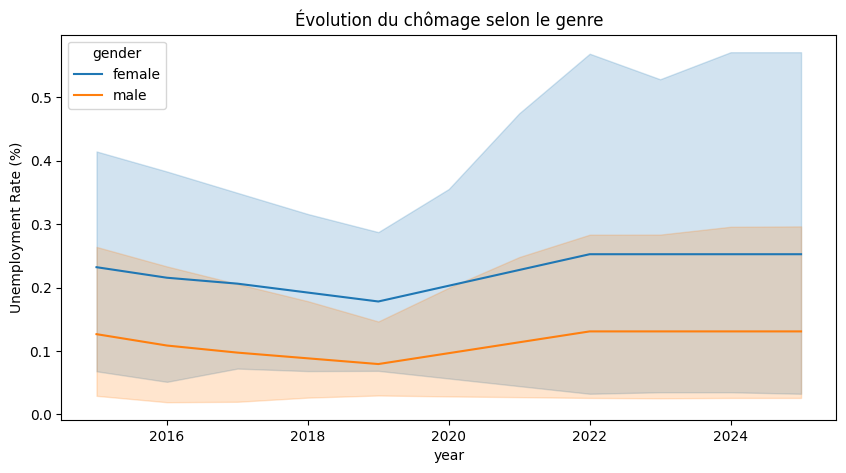

In [3]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=civ_unemployed_clean,
    x="year",
    y="unemployment_rate",
    hue="gender",
    estimator="mean"
)

plt.title("Évolution du chômage selon le genre")
plt.ylabel("Unemployment Rate (%)")
plt.show()

## 3. Analyse Approfondie : Genre, Tranche d'Âge et Éducation

Extraction des 10 segments de la population subissant les taux de chômage moyens les plus élevés. Les données sont regroupées simultanément selon trois dimensions : le genre, la tranche d'âge, et le niveau d'études.

In [4]:
grouped = (
    civ_unemployed_clean.groupby(
        ["gender", "age_group", "education_level"]
    )["unemployment_rate"]
    .mean()
    .sort_values(ascending=False)
)

grouped.head(10)

gender  age_group  education_level  
female  15-24      Tertiary             0.618179
male    15-24      Tertiary             0.360571
female  15-24      Upper secondary      0.319101
male    15-24      Upper secondary      0.112219
female  15-24      Lower secondary      0.110705
male    15-24      Lower secondary      0.049369
female  15-24      Primary              0.049076
                   Less than primary    0.023612
male    15-24      Primary              0.020146
                   Less than primary    0.019092
Name: unemployment_rate, dtype: float64

## 4. Corrélation entre Niveau d'Éducation et Chômage par Genre

Création d'une matrice thermique (Heatmap) croisant le niveau d'études et le genre. Ce visuel permet d'identifier d'un coup d'œil si l'élévation du niveau d'instruction (du primaire au supérieur) protège efficacement contre le chômage, ou si elle accentue les disparités hommes-femmes.

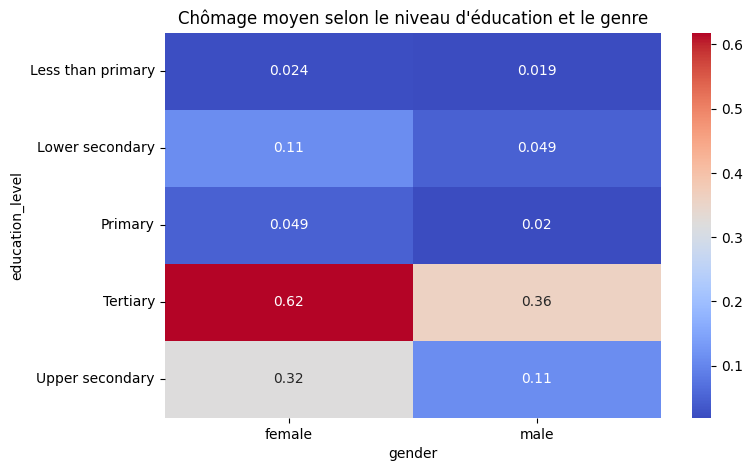

In [5]:
pivot = civ_unemployed_clean.pivot_table(
    values="unemployment_rate",
    index="education_level",
    columns="gender",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm"
)

plt.title("Chômage moyen selon le niveau d'éducation et le genre")
plt.show()

## 5. Analyse de la Distribution et Dispersion du Chômage

Génération d'une boîte à moustaches (Boxplot) afin d'étudier la distribution globale, la médiane, la volatilité et la présence d'écarts extrêmes dans les taux de chômage enregistrés pour chaque genre.

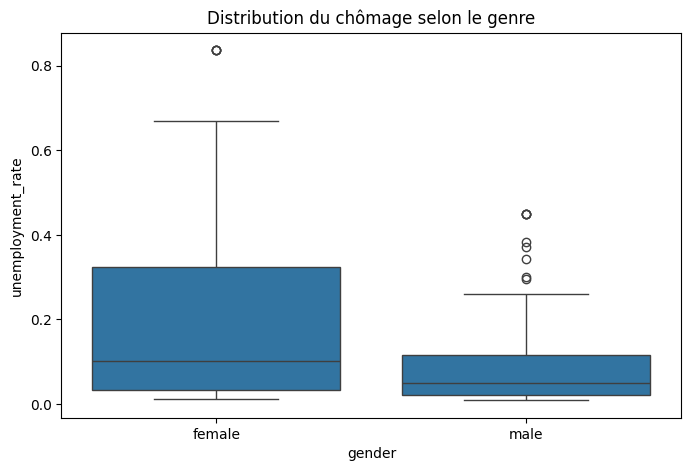

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=civ_unemployed_clean,
    x="gender",
    y="unemployment_rate"
)

plt.title("Distribution du chômage selon le genre")
plt.show()

## 6. Analyse de Corrélation : Chômage vs Inactivité

Construction d'un graphique en nuage de points (Scatter plot) pour analyser la relation entre le taux de chômage et le taux d'inactivité (inactivity_rate).L'objectif est de voir si une forte inactivité coïncide avec un chômage élevé et comment se comportent les profils masculins et féminins face à ces deux indicateurs.

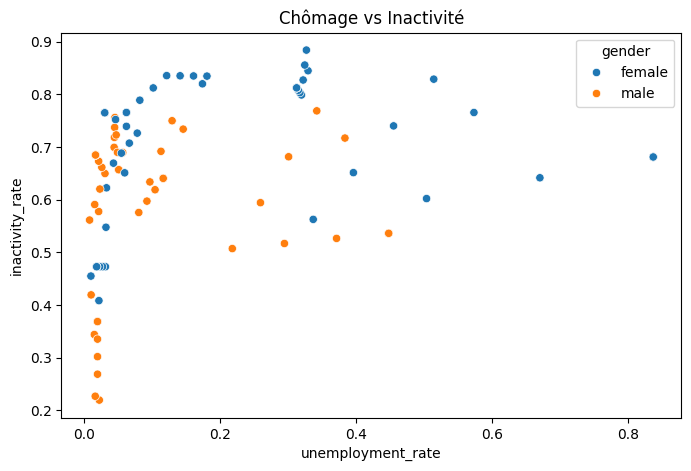

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=civ_unemployed_clean,
    x="unemployment_rate",
    y="inactivity_rate",
    hue="gender"
)

plt.title("Chômage vs Inactivité")
plt.show()